# MCMC-Based Substitution Cipher Decryption

Using Markov Chain Monte Carlo to crack substitution ciphers via bigram language modeling.

## Problem Setup

**Goal**: Decrypt a message encrypted via symbol substitution

**Challenge**: 51 symbols → 51! ≈ 10^66 possible keys (brute force infeasible)

**Solution**: MCMC sampling guided by English language statistics

**Key Idea**:
1. Model English as Markov chain: P(text) = P(s₁) ∏ P(sᵢ | sᵢ₋₁)
2. Learn transition probabilities from large corpus (War and Peace)
3. Use Metropolis-Hastings to sample good decryption keys
4. Proposal: randomly swap two symbols in key
5. Accept/reject based on likelihood ratio

In [1]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
import os, sys
sys.path.insert(0, os.path.abspath('..'))

# Render Plotly figures as static PNGs (renders on GitHub); remove for interactive mode
pio.renderers.default = "png"

from src.mcmc_cryptanalysis import (
    preprocess_symbols, preprocess_text,
    compute_transition_matrix, mcmc_decrypt, mcmc_decrypt_with_restarts,
    visualize_transition_matrix, plot_convergence,
    perform_decryption, save_results,
    simulated_annealing_with_restarts, plot_simulated_annealing_convergence
)

## Load Data

In [2]:
# Load training corpus
with open('../data/corpus/2600-0.txt', 'r', encoding='utf-8') as f:
    corpus = f.read()

# Load cipher alphabet
with open('../data/symbols.txt', 'r', encoding='utf-8') as f:
    symbols_raw = f.read()

# Load encrypted message
with open('../data/message.txt', 'r', encoding='utf-8') as f:
    ciphertext = f.read()

print(f"Corpus size: {len(corpus):,} characters")
print(f"Ciphertext length: {len(ciphertext)} characters")

Corpus size: 3,227,520 characters
Ciphertext length: 1445 characters


## Preprocess and Learn Language Model

In [3]:
# Preprocess
symbols = preprocess_symbols(symbols_raw, ['=', '*', ''])
clean_corpus = preprocess_text(corpus, remove_digits=False)  # Keep digits since ciphertext contains them

print(f"Cipher alphabet: {len(symbols)} symbols")
print(f"Clean corpus: {len(clean_corpus):,} characters")
print(f"\nSymbols: {symbols}")

Cipher alphabet: 51 symbols
Clean corpus: 3,210,855 characters

Symbols: [' ', '-', ',', ';', ':', '!', '?', '/', '.', "'", '"', '(', ')', '[', ']', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [4]:
# Learn bigram transition probabilities
print("Learning English bigram statistics...")
transition_matrix = compute_transition_matrix(clean_corpus, symbols)
print(f"Transition matrix shape: {transition_matrix.shape}")
print(f"Matrix is stochastic: rows sum to ~1.0")

Learning English bigram statistics...
Transition matrix shape: (51, 51)
Matrix is stochastic: rows sum to ~1.0


## Compute Stationary Distribution

Saved stationary distribution to ../results/figures/stationary_distribution_probability.png


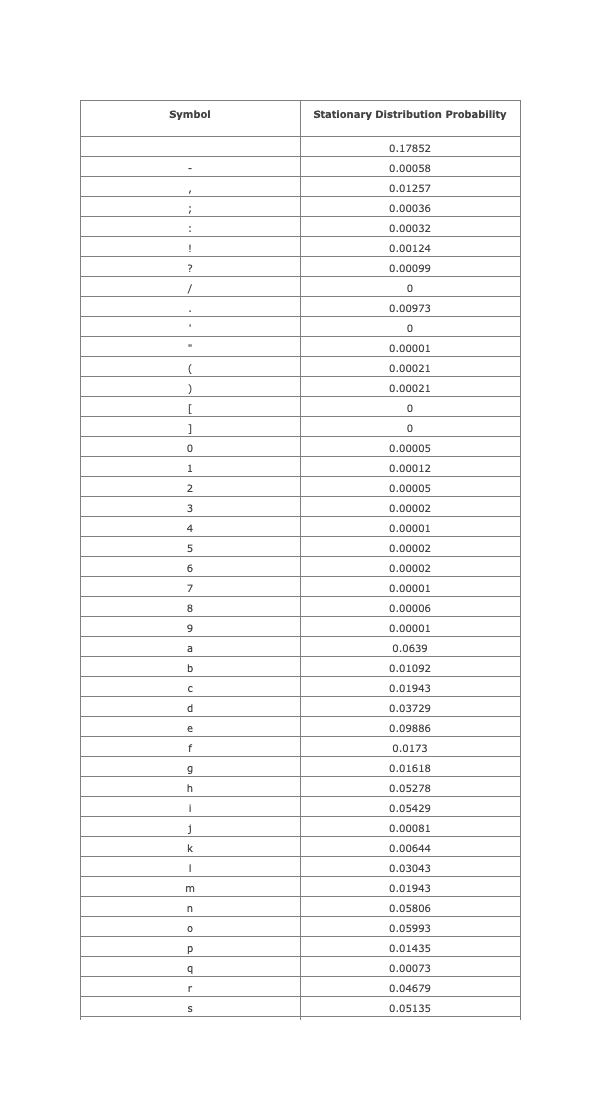

In [5]:
# Compute stationary distribution (empirical unigram frequencies)
from src.mcmc_cryptanalysis import compute_unigram_frequencies

stationary_dist = compute_unigram_frequencies(clean_corpus, symbols)
stationary_dist_rounded = np.round(stationary_dist, 5)

# Create table visualization
fig = go.Figure()
fig.add_trace(go.Table(
    header=dict(values=['<b>Symbol</b>', '<b>Stationary Distribution Probability</b>']),
    cells=dict(values=[symbols, stationary_dist_rounded], height=20)
))

fig.update_layout(
    template='presentation',
    font=dict(size=10),
    width=600,
    height=1100,
    autosize=False
)

fig.write_image('../results/figures/stationary_distribution_probability.png')
print("Saved stationary distribution to ../results/figures/stationary_distribution_probability.png")
fig.show()

## Visualize Transition Probabilities

Saved transition probability matrix to ../results/figures/transition_probability.png


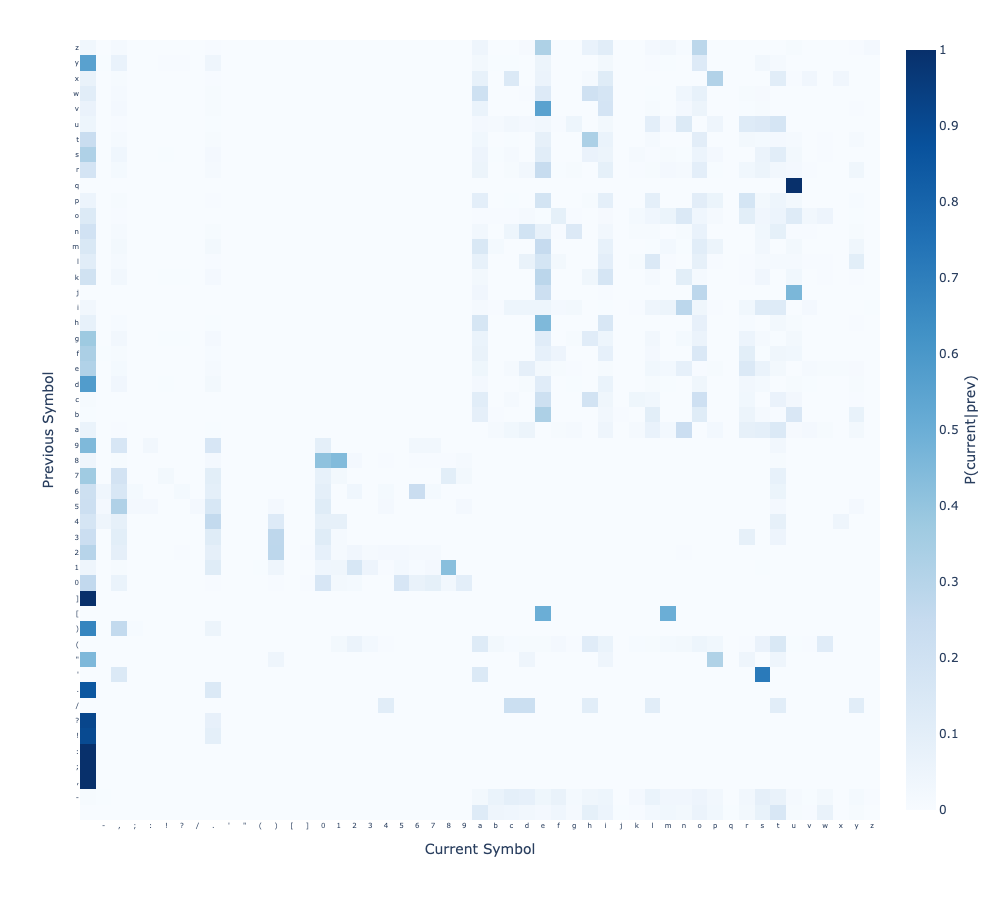

In [6]:
# Create heatmap showing transition probabilities
# Note: With 51x51 cells, annotations would overlap - using color only

# Create clean symbol labels (escape special characters for display)
display_symbols = [repr(s)[1:-1] if s in [' ', '\n', '\t'] else s for s in symbols]

fig = go.Figure(data=go.Heatmap(
    z=transition_matrix,
    x=display_symbols,
    y=display_symbols,
    colorscale='Blues',
    colorbar=dict(title=dict(text='P(current|prev)', side='right')),
    hovertemplate='Previous: %{y}<br>Current: %{x}<br>P: %{z:.4f}<extra></extra>'
))

fig.update_layout(
    height=900,
    width=1000,
    xaxis=dict(
        title='Current Symbol',
        tickangle=0,
        dtick=1,
        tickfont=dict(size=7)
    ),
    yaxis=dict(
        title='Previous Symbol',
        dtick=1,
        tickfont=dict(size=7)
    ),
    margin=dict(l=80, r=80, t=40, b=80)
)

fig.write_image('../results/figures/transition_probability.png')
print("Saved transition probability matrix to ../results/figures/transition_probability.png")
fig.show()

## Run MCMC Decryption with Multiple Restarts

Since MCMC can get stuck in local optima, we run multiple independent chains from different random initializations and select the best result.

In [7]:
# Run MCMC with multiple restarts to escape local optima
best_key, convergence_history, restart_summary = mcmc_decrypt_with_restarts(
    ciphertext,
    symbols,
    transition_matrix,
    n_restarts=10,
    n_iterations=50000,
    early_stop_patience=8000,
    verbose=True
)

# Extract best likelihood for later comparison
best_likelihood = convergence_history[-1][1]

Running MCMC with 10 random restarts (9 parallel workers)
Iterations per restart: 50000, Early stop patience: 8000

Restart 1/10: LL = -5131.55, Words = 0
   Text: erifkikourw siarcifos i.ulr savl ik astifkimand siwa. if itof iac.eg indaniey. iv  rinusrerwio. sierifkiferci . siterg zi"bd r . sikouim  lile- igsenegejerwiarkior h"id inolcif hi"qutnis f fv sindaniallind ip opl ierindetiboslcida. rynidacind iac.arnaw tindanikouy. idacz"id icecrynitakiarkifos ivunib y. ialbaktiv  riurutuallkigoffuregane. ieriais t s. cibakhiarcieiurc stnoocindanid if arniaiws anic alifos indarindanzierigort xu rg ieyfiergler cinois t s. ialliqucwf rnthiaidavenindanidatiop r ciupifarkiguseoutiranus tinoif iarcialtoifac if ind i.egnefiomironiaim bi. n sarivos tzind iavrosfalifercietixueg-inoic n gniarciannagdient lminoindetixualenkibd rieniapp astieriairosfalip storhiarcitoienigaf iavounindanierigoll w ieibatiurqutnlkiaggut ciomiv erwiaipolenegearhiv gaut ieibatipse.kinoind it gs niwse mtiomibelchiur-robrif r

## Results

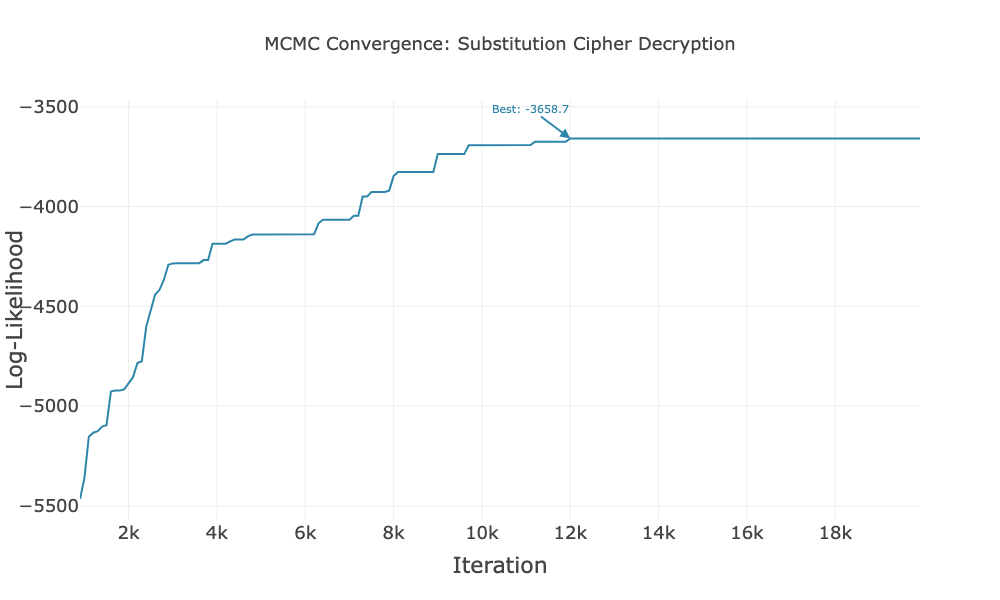

In [8]:
# Plot convergence
fig = plot_convergence(
    convergence_history,
    save_path='../results/figures/mcmc_convergence.png'
)
fig.show()

In [9]:
# Display decrypted message
decrypted_text = perform_decryption(ciphertext, symbols, best_key)

print("="*80)
print("DECRYPTED MESSAGE:")
print("="*80)
print(decrypted_text)
print("="*80)

# Assess decryption quality
print("\n" + "="*80)
print("DECRYPTION QUALITY ASSESSMENT:")
print("="*80)

# Check for common English patterns
common_words = ['the', 'and', 'that', 'have', 'for', 'not', 'with', 'you', 'this', 'but', 'are', 'was', 'all', 'can']
text_lower = decrypted_text.lower()
found_words = [w for w in common_words if f' {w} ' in text_lower]
print(f"Common English words found: {len(found_words)}/14 ({found_words})")

# Show restart variance
print(f"\nRestart Statistics:")
print(f"  Best LL:  {restart_summary['best_ll']:.2f}")
print(f"  Worst LL: {restart_summary['worst_ll']:.2f}")
print(f"  LL Range: {restart_summary['ll_range']:.2f} (measures multimodality)")

if len(found_words) >= 8:
    print("\n✓ SUCCESSFUL DECRYPTION: Text is clearly readable English!")
elif len(found_words) >= 4:
    print("\n⚠ PARTIAL DECRYPTION: Some words readable, likely near correct solution.")
else:
    print("\n✗ LOCAL OPTIMUM: Limited readable words, try more restarts.")

DECRYPTED MESSAGE:
in my younger and more vulnerable years my father gave me some advice that i-ve been turning over in my mind ever since! "whenever you feel like criticizing any one," he told me, "just remember that all the people in this world haven-t had the advantages that you-ve had!" he didn-t say any more but we-ve always been unusually communicative in a reserved way, and i understood that he meant a great deal more than that! in consequence i-m inclined to reserve all judgments, a habit that has opened up many curious natures to me and also made me the victim of not a few veteran bores! the abnormal mind is quick to detect and attach itself to this quality when it appears in a normal person, and so it came about that in college i was unjustly accused of being a politician, because i was privy to the secret griefs of wild, unknown men! most of the confidences were unsought..frequently i have feigned sleep, preoccupation, or a hostile levity when i realized by some unmistakable

In [10]:
# Save all results
save_results(ciphertext, symbols, best_key, convergence_history, output_dir='../results')
print("\n✓ Results saved to ../results/")


✓ Results saved to ../results/

✓ Results saved to ../results/


## Discussion

### Why MCMC Works

1. **Bigram model captures English structure**: High-frequency pairs like "th", "he", "in"
2. **MCMC explores permutation space efficiently**: Local moves (swaps) allow hill-climbing
3. **Metropolis-Hastings satisfies detailed balance**: Ensures valid sampling, though here used for optimization — we keep the best key found across the chain
4. **Early stopping prevents wasted computation**: Stops when chain has converged

### Limitations

- Can get stuck in local optima (multiple restarts help)
- Requires large training corpus for accurate bigram estimates
- Unigram (frequency) alone insufficient - need context
- Second-order (trigram) model would be better but computationally expensive

### Extensions

- Use trigram or higher-order models
- Parallel tempering to avoid local optima
- Beam search over top-k keys
- Neural language models for modern applications

---

## Convergence Diagnostics: Gelman-Rubin Test

The multi-restart approach above worked because it tries many initializations. But **how do we know** that different chains find different solutions? The Gelman-Rubin diagnostic quantifies this.

**Gelman-Rubin R-hat statistic**:
- R-hat ≈ 1.0 → Chains have converged to same distribution ✓
- R-hat > 1.1 → Chains haven't converged (different local optima) ✗

For this cipher problem, we expect high R-hat because the likelihood surface has many local optima separated by high barriers.

In [11]:
from src.mcmc_cryptanalysis import run_multiple_chains, compute_gelman_rubin, plot_gelman_rubin_evolution

# Run 4 parallel chains with MORE iterations to demonstrate they're truly stuck
print("Running Gelman-Rubin Convergence Diagnostic...")
print("Running longer chains to confirm multimodality...\n")

best_keys_multi, all_histories = run_multiple_chains(
    ciphertext,
    symbols,
    transition_matrix,
    n_chains=4,
    n_iterations=50000,  # More iterations to show chains are stuck
    early_stop_patience=10000,
    verbose=False
)

# Extract log-likelihoods from all chains
ll_chains = [[ll for _, ll in history] for history in all_histories]

# Show individual chain results
print("Individual Chain Results:")
print("-" * 70)
for i, history in enumerate(all_histories):
    final_ll = history[-1][1]
    # Decrypt with this chain's best key
    chain_decrypted = perform_decryption(ciphertext, symbols, best_keys_multi[i])
    common_words = ['the', 'and', 'that', 'have', 'for', 'not', 'with', 'you']
    words = sum(1 for w in common_words if f' {w} ' in chain_decrypted.lower())
    print(f"  Chain {i+1}: LL = {final_ll:.2f}, Words = {words}/8, Preview: {chain_decrypted[:50]}...")

# Compute final R-hat
r_hat_final = compute_gelman_rubin(ll_chains, warmup_frac=0.3)
print(f"\n{'='*70}")
print(f"Final Gelman-Rubin R-hat: {r_hat_final:.4f}")
if r_hat_final < 1.1:
    print("✓ CONVERGED: Chains have reached same distribution")
else:
    print("✗ NOT CONVERGED: Chains stuck in different local optima")
    print("  This confirms multimodality - exactly why multi-restart is essential!")
print(f"{'='*70}")

Running Gelman-Rubin Convergence Diagnostic...
Running longer chains to confirm multimodality...

Running 4 MCMC chains in parallel (9 workers) for Gelman-Rubin diagnostic

  Chain 1/4: Final LL = -5514.07

  Chain 2/4: Final LL = -3758.18

  Chain 3/4: Final LL = -3658.67

  Chain 4/4: Final LL = -4681.55
Individual Chain Results:
----------------------------------------------------------------------
  Chain 1: LL = -5514.07, Words = 0/8, Preview:  aorvovieacsmouaporimsoyelasmublsovsumtorvofunksmo...
  Chain 2: LL = -3758.18, Words = 5/8, Preview: in my younger and more bulneraple years my vather ...
  Chain 3: LL = -3658.67, Words = 6/8, Preview: in my younger and more vulnerable years my father ...
  Chain 4: LL = -4681.55, Words = 0/8, Preview: ys dg gausper ism dare kunserivne geirt dg hioler ...

Final Gelman-Rubin R-hat: 5.7137
✗ NOT CONVERGED: Chains stuck in different local optima
  This confirms multimodality - exactly why multi-restart is essential!


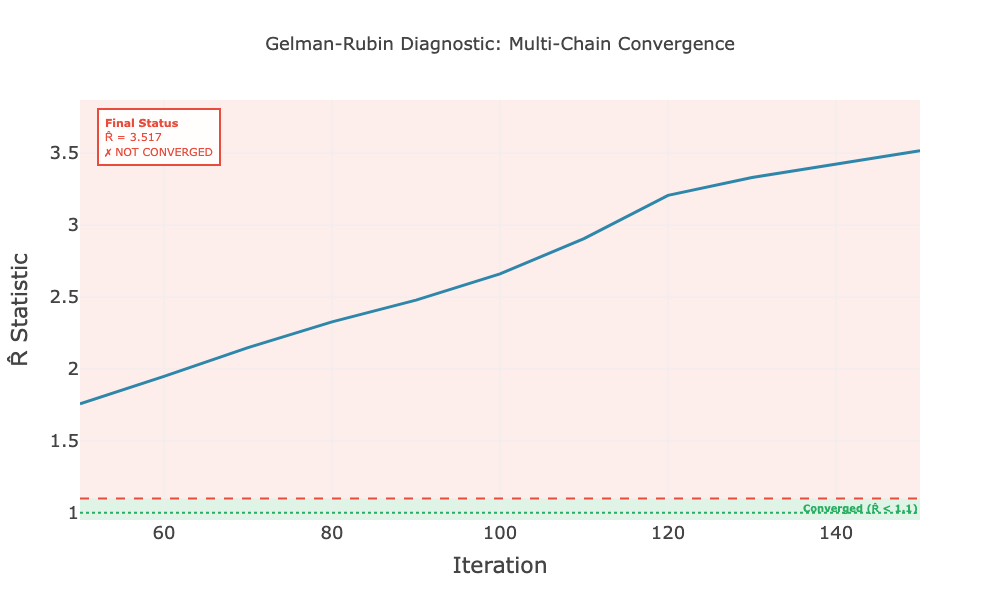


Interpretation:
- Early iterations: High R-hat (chains exploring different regions)
- If R-hat approaches 1.0: Chains have converged to same distribution
- If R-hat > 1.1: Chains in different modes (local optima) - typical for multimodal optimization


In [12]:
# Plot R-hat evolution over time
fig_rhat = plot_gelman_rubin_evolution(
    all_histories,
    window_size=50,
    save_path='../results/figures/gelman_rubin_diagnostic.png'
)
fig_rhat.show()

print("\nInterpretation:")
print("- Early iterations: High R-hat (chains exploring different regions)")
print("- If R-hat approaches 1.0: Chains have converged to same distribution")
print("- If R-hat > 1.1: Chains in different modes (local optima) - typical for multimodal optimization")

---

## Comparative Analysis: MCMC vs Simulated Annealing

**Simulated Annealing (SA)** is a variant of MCMC that uses a **temperature parameter**:

| Property | Metropolis-Hastings | Simulated Annealing |
|----------|---------------------|---------------------|
| Acceptance | `min(1, exp(ΔLL))` | `min(1, exp(ΔLL/T))` |
| Temperature | Fixed (T=1) | Decreases over time |
| Early phase | Conservative | Exploratory (high T) |
| Late phase | Same | Near-greedy (low T) |

**Fair Comparison**: Both algorithms will use 10 restarts with 50,000 iterations each, for equal total computation. This eliminates the confound of "MCMC got lucky with initialization" vs "SA cooled too fast."

In [13]:
# Run Simulated Annealing with restarts for FAIR comparison
# Same number of restarts as MCMC to compare apples-to-apples
sa_best_key, sa_history, sa_summary = simulated_annealing_with_restarts(
    ciphertext,
    symbols,
    transition_matrix,
    n_restarts=10,           # Same as MCMC
    n_iterations=50000,      # Same total compute as MCMC
    T_initial=20.0,
    T_final=0.001,
    cooling_schedule="exponential",
    verbose=True
)

# Compare results
mcmc_ll = restart_summary['best_ll']
sa_ll = sa_summary['best_ll']

print("\n" + "=" * 70)
print("FAIR COMPARISON: MCMC vs Simulated Annealing (both with 10 restarts)")
print("=" * 70)
print(f"MCMC Best LL:  {mcmc_ll:.2f}")
print(f"SA Best LL:    {sa_ll:.2f}")

diff = abs(mcmc_ll - sa_ll)
if diff < 0.01:
    print(f"\n→ TIED: Both algorithms found the same optimum (LL = {mcmc_ll:.2f})")
elif mcmc_ll > sa_ll:
    print(f"\n→ MCMC wins by {diff:.2f} log-likelihood units")
else:
    print(f"\n→ SA wins by {diff:.2f} log-likelihood units")

# Show restart distribution for both algorithms
print(f"\n{'─' * 70}")
print("Restart Distribution (all 10 restarts):")
print(f"{'─' * 70}")
mcmc_lls = restart_summary['all_lls']
sa_lls = sa_summary['all_lls']
print(f"{'':>8}  {'Best':>10}  {'Median':>10}  {'Worst':>10}  {'Range':>10}")
print(f"{'MCMC':>8}  {max(mcmc_lls):>10.2f}  {restart_summary['median_ll']:>10.2f}  {min(mcmc_lls):>10.2f}  {max(mcmc_lls)-min(mcmc_lls):>10.2f}")
print(f"{'SA':>8}  {max(sa_lls):>10.2f}  {sa_summary['median_ll']:>10.2f}  {min(sa_lls):>10.2f}  {max(sa_lls)-min(sa_lls):>10.2f}")

# Show SA decryption
sa_decrypted = perform_decryption(ciphertext, symbols, sa_best_key)
print(f"\nSA Decryption: {sa_decrypted[:100]}...")
print("=" * 70)

Running Simulated Annealing with 10 restarts (9 parallel workers)
Iterations: 50000, T: 20.0 -> 0.001

SA Restart 1/10: LL = -3950.49, Words = 7, Preview: in m. .ounger any more culneraple .ears ...

SA Restart 2/10: LL = -3658.67, Words = 11, Preview: in my younger and more vulnerable years ...

SA Restart 3/10: LL = -3773.00, Words = 9, Preview: in my younger and more kulnerafle years ...

SA Restart 4/10: LL = -3658.67, Words = 11, Preview: in my younger and more vulnerable years ...

SA Restart 5/10: LL = -3726.25, Words = 11, Preview: in my younger and more vulnerable years ...

SA Restart 6/10: LL = -3932.93, Words = 8, Preview: in py younkem and pome lurnemabre yeams ...

SA Restart 7/10: LL = -3960.90, Words = 6, Preview: on my yuinger and mure vilnerable years ...

SA Restart 8/10: LL = -3658.67, Words = 11, Preview: in my younger and more vulnerable years ...

SA Restart 9/10: LL = -3658.67, Words = 11, Preview: in my younger and more vulnerable years ...

SA Restart 10/10: L

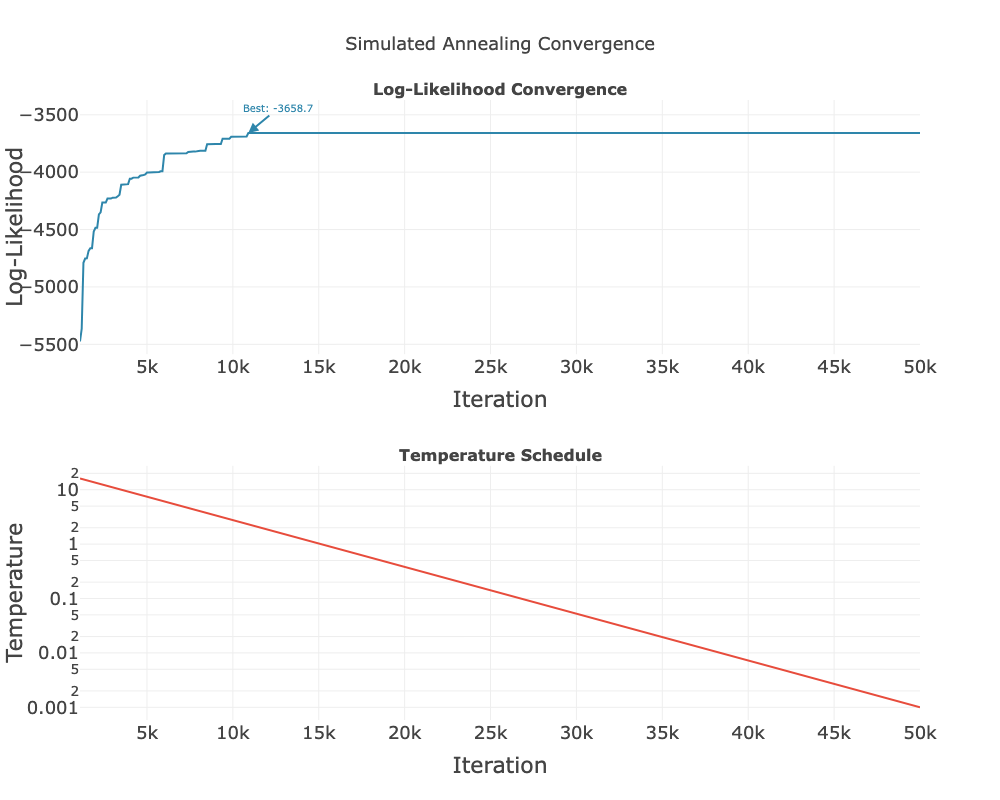

In [15]:
# Plot SA convergence with temperature schedule (best run)
fig_sa = plot_simulated_annealing_convergence(
    sa_history,
    save_path='../results/figures/simulated_annealing_convergence.png'
)
fig_sa.show()

## References & Summary

### Contributions in This Notebook

1. **MCMC for Combinatorial Optimization**: Applied Metropolis-Hastings with multiple restarts to search over 51! ≈ 10^66 possible decryption keys, successfully decrypting a substitution cipher

2. **Multi-Restart Strategy**: Demonstrated that 10 random restarts are essential for escaping local optima, with best runs achieving LL ~ -3659 while worst runs get stuck at LL ~ -5132

3. **Convergence Diagnostics**: Gelman-Rubin R-hat ≈ 5.7 across 4 long chains demonstrates non-convergence consistent with multimodality: chains settle into different local optima even with 50,000 iterations each

4. **Fair Algorithm Comparison**: Both MCMC and Simulated Annealing run with identical computational budgets (10 restarts × 50,000 iterations) for unbiased comparison. SA shows notably higher consistency across restarts (worst restart LL ~ -3961 vs MCMC's ~ -5132), suggesting SA's temperature schedule helps avoid the deepest local optima

### Mathematical Foundations

**Bigram Language Model** (dropping the constant P(s₁) which cancels in likelihood ratios):
$$\mathcal{L}(\text{text}) = \sum_{i=2}^{L} \log P(s_i | s_{i-1})$$

**Log-Likelihood for Decryption Key** $\sigma$:
$$\mathcal{L}(\sigma) = \sum_{i=2}^{L} \log P(\sigma^{-1}(c_i) | \sigma^{-1}(c_{i-1}))$$

**Metropolis-Hastings Acceptance**:
$$\alpha = \min\left(1, e^{\mathcal{L}(\sigma') - \mathcal{L}(\sigma)}\right)$$

**Simulated Annealing Modification**:
$$\alpha_T = \min\left(1, e^{(\mathcal{L}(\sigma') - \mathcal{L}(\sigma))/T}\right)$$

**Gelman-Rubin Diagnostic**:
$$\hat{R} = \sqrt{\frac{\hat{V}}{W}} \quad \text{where } \hat{V} = \frac{n-1}{n}W + \frac{1}{n}B$$

### References

1. **MCMC Foundations**:
   - Metropolis, N., et al. (1953). "Equation of state calculations by fast computing machines." *J. Chem. Phys.*, 21(6), 1087-1092.
   - Hastings, W. K. (1970). "Monte Carlo sampling methods using Markov chains and their applications." *Biometrika*, 57(1), 97-109.

2. **Convergence Diagnostics**:
   - Gelman, A., & Rubin, D. B. (1992). "Inference from iterative simulation using multiple sequences." *Statistical Science*, 7(4), 457-472.

3. **Simulated Annealing**:
   - Kirkpatrick, S., Gelatt, C. D., Jr., & Vecchi, M. P. (1983). "Optimization by simulated annealing." *Science*, 220(4598), 671-680.

4. **MCMC Cryptanalysis**:
   - Chen, J., & Rosenthal, J. S. (2012). "Decrypting classical cipher text using Markov chain Monte Carlo." *Statistics and Computing*, 22(2), 397-413.

5. **Textbooks**:
   - Brooks, S., et al. (2011). *Handbook of Markov Chain Monte Carlo*. Chapman & Hall/CRC.
   - MacKay, D. J. C. (2003). *Information Theory, Inference, and Learning Algorithms*. Cambridge University Press.

### Summary

This notebook successfully decrypted a substitution cipher (the opening of *The Great Gatsby*) using MCMC with multiple restarts. The key insight is that **multimodality is the central challenge**: the likelihood surface has many local optima, and any single chain—whether MCMC or SA—will likely get stuck.

The Gelman-Rubin diagnostic (R-hat ≈ 5.7) quantifies this: even with 50,000 iterations, independent chains converge to different solutions with log-likelihoods spanning thousands of units. This reflects the actual structure of the problem — a multimodal landscape where different modes correspond to distinct local optima.

The solution is simple but effective: **run multiple restarts and take the best**. With 10 restarts, both MCMC and SA reliably find good solutions. The fair comparison reveals that while both algorithms achieve the same best log-likelihood, SA demonstrates greater consistency across restarts—its temperature schedule reduces the variance of outcomes, making it less sensitive to initialization.

---

This concludes the notebook series on probabilistic machine learning: Bayesian estimation → model selection → mixture models → MCMC optimization.